In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
def percentDiff(x1,x2):
    return abs(x1 - x2)/abs(x1) * 100

In [3]:
simulation_results = pd.read_csv("Hamiltonian-based-inverse+surrogate_Ansys_results.csv")
ML_results = pd.read_csv("Hamiltonian-based-inverse+surrogate_MLP_results.csv")
simulation_results = simulation_results.drop(simulation_results.index[[14, 16, 67]])

# Compare reference and machine learning predicted design results

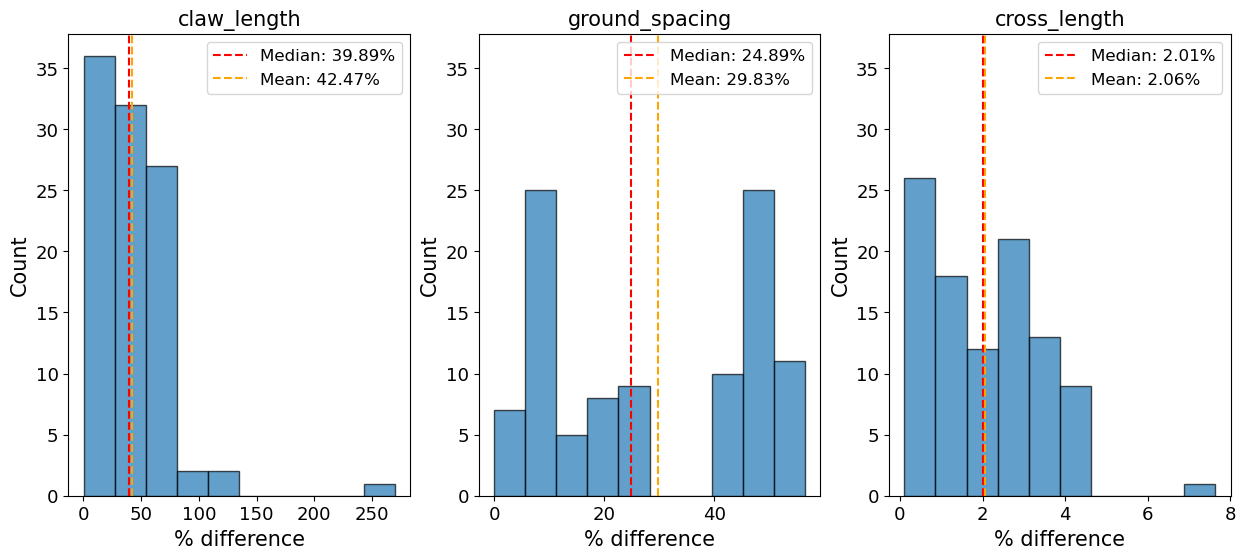

In [4]:
fig,ax = plt.subplots(1,3,figsize = (15,6))

ref_claw_length = ML_results["ref_connection_pads.readout.claw_length"].to_numpy()
ref_ground_spacing = ML_results["ref_connection_pads.readout.ground_spacing"].to_numpy()
ref_cross_length =  ML_results["ref_cross_length"].to_numpy()

pred_claw_length = ML_results["pred_connection_pads.readout.claw_length"].to_numpy()
pred_ground_spacing = ML_results["pred_connection_pads.readout.ground_spacing"].to_numpy()
pred_cross_length =  ML_results["pred_cross_length"].to_numpy()

pd_claw_length = percentDiff(ref_claw_length,pred_claw_length)
pd_ground_spacing = percentDiff(ref_ground_spacing,pred_ground_spacing)
pd_cross_length = percentDiff(ref_cross_length,pred_cross_length)

ax[0].hist(pd_claw_length,ec="black",alpha = 0.7)
ax[1].hist(pd_ground_spacing,ec="black",alpha = 0.7)
ax[2].hist(pd_cross_length,ec="black",alpha = 0.7)

mean_claw_length = np.mean(pd_claw_length)
median_claw_length = np.median(pd_claw_length)
mean_ground_spacing = np.mean(pd_ground_spacing)
median_ground_spacing = np.median(pd_ground_spacing)
mean_cross_length = np.mean(pd_cross_length)
median_cross_length = np.median(pd_cross_length)

ylims = ax[0].get_ylim()
ax[0].set_ylim(ylims[0],ylims[1])
ax[1].set_ylim(ylims[0],ylims[1])
ax[2].set_ylim(ylims[0],ylims[1])

ax[0].vlines(median_claw_length,ylims[0],ylims[1],color = "red",linestyle = "dashed",label = "Median: {}%".format(np.round(median_claw_length,2)))
ax[0].vlines(mean_claw_length,ylims[0],ylims[1],color = "orange",linestyle = "dashed",label = "Mean: {}%".format(np.round(mean_claw_length,2)))
ax[1].vlines(median_ground_spacing,ylims[0],ylims[1],color = "red",linestyle = "dashed",label = "Median: {}%".format(np.round(median_ground_spacing,2)))
ax[1].vlines(mean_ground_spacing,ylims[0],ylims[1],color = "orange",linestyle = "dashed",label = "Mean: {}%".format(np.round(mean_ground_spacing,2)))
ax[2].vlines(median_cross_length,ylims[0],ylims[1],color = "red",linestyle = "dashed",label = "Median: {}%".format(np.round(median_cross_length,2)))
ax[2].vlines(mean_cross_length,ylims[0],ylims[1],color = "orange",linestyle = "dashed",label = "Mean: {}%".format(np.round(mean_cross_length,2)))

ax[0].legend(fontsize = 12)
ax[1].legend(fontsize = 12)
ax[2].legend(fontsize = 12)

ax[0].set_title(r"claw_length",fontsize = 15)
ax[0].set_ylabel("Count",fontsize = 15)
ax[0].set_xlabel("% difference",fontsize = 15)
ax[1].set_title(r"ground_spacing",fontsize = 15)
ax[1].set_ylabel("Count",fontsize = 15)
ax[1].set_xlabel("% difference",fontsize = 15)
ax[2].set_title(r"cross_length",fontsize = 15)
ax[2].set_ylabel("Count",fontsize = 15)
ax[2].set_xlabel("% difference",fontsize = 15)

ax[0].tick_params("x",labelsize = 13)
ax[0].tick_params("y",labelsize = 13)
ax[1].tick_params("y",labelsize = 13)
ax[1].tick_params("x",labelsize = 13)
ax[2].tick_params("y",labelsize = 13)
ax[2].tick_params("x",labelsize = 13)

# plt.title("Percent Difference (Design Parameters)")
# plt.ylabel("Percent different [%]")

## Compare reference and machine learning predicted Hamiltonian params (scatter plot format)

Text(0, 0.5, 'Percent different [%]')

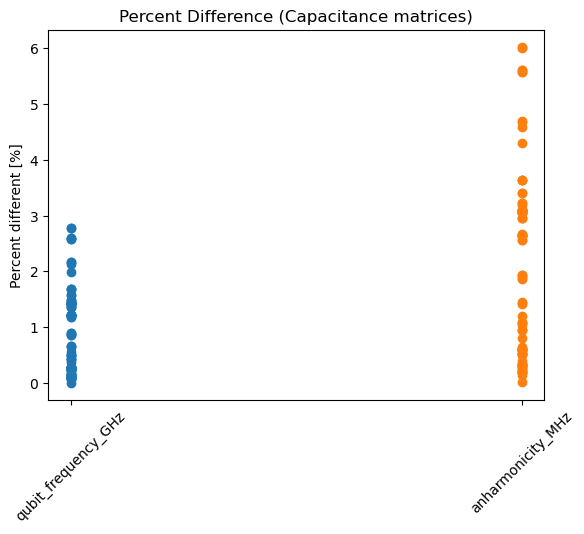

In [5]:
fig,ax = plt.subplots()
colors = ["C0","C1","C2","C3","C4","C5"]
for sample in range(len(simulation_results)):
    
    pred_H = eval(simulation_results.pred_H_params.iloc[sample])
    ref_H = eval(simulation_results.ref_H_params.iloc[sample])

    color_num = 0
    for matrix_element in list(pred_H.keys()):
        diff = percentDiff(ref_H[matrix_element],pred_H[matrix_element])
        plt.scatter(matrix_element,diff,color = [colors[color_num]])
        color_num += 1
    color_num = 0

plt.xticks(rotation=45)

plt.title("Percent Difference (Capacitance matrices)")
plt.ylabel("Percent different [%]")

# Compare Hamiltonian parameters by Sample ID

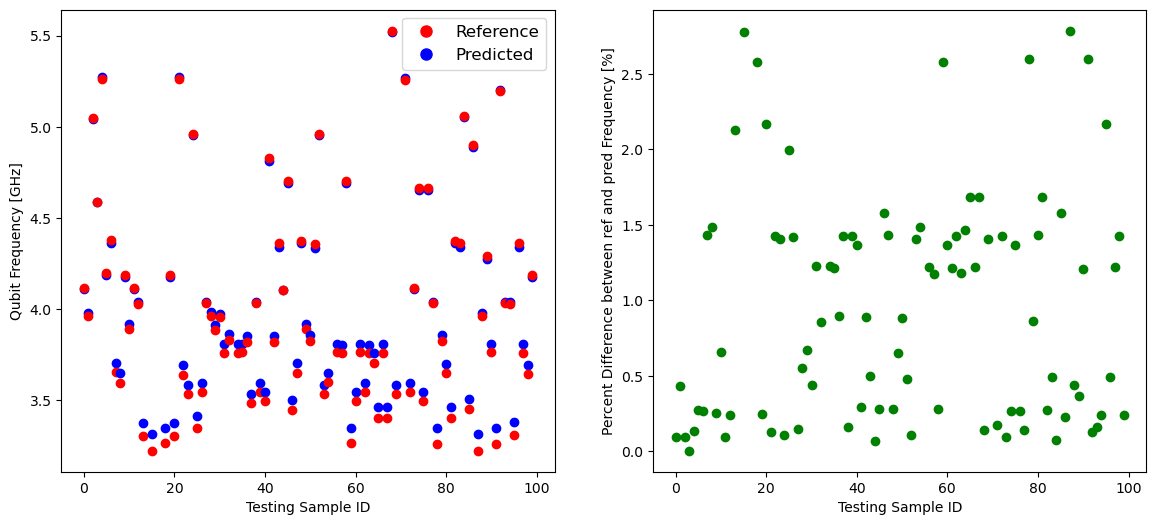

In [6]:
fig,ax = plt.subplots(1,2,figsize = (14,6))
Samples = simulation_results.Sample.to_numpy()

over1 = []
under1 = []
all_diffs_f = []

for sample in Samples:
    
    predicted_f = eval(simulation_results[simulation_results.Sample == sample].pred_H_params.iloc[0])["qubit_frequency_GHz"]
    reference_f = eval(simulation_results[simulation_results.Sample == sample].ref_H_params.iloc[0])["qubit_frequency_GHz"]

    diff_f = percentDiff(reference_f,predicted_f)
    all_diffs_f.append(diff_f)

    if diff_f > 50:
        print(sample)

    ax[0].scatter([sample],[predicted_f],color = 'blue')
    ax[0].scatter([sample],[reference_f],color = 'red')
    ax[0].set_xlabel("Testing Sample ID")
    ax[0].set_ylabel("Qubit Frequency [GHz]")


    ax[1].scatter([sample],[diff_f],color = 'green')

    ax[1].set_xlabel("Testing Sample ID")
    ax[1].set_ylabel("Percent Difference between ref and pred Frequency [%]")


legend_elements = [
    Line2D([0], [0], marker='o', color='red',
           linestyle='None', markersize=8, label='Reference'),
    Line2D([0], [0], marker='o', color='blue',
           linestyle='None', markersize=8, label='Predicted'),
]

ax[0].legend(handles=legend_elements,fontsize = 12)


# legend_elements = [
#     Line2D([0], [0], marker='o', color='green',
#            linestyle='None', markersize=8, label='|p| < 1%'),
#     Line2D([0], [0], marker='o', color='red',
#            linestyle='None', markersize=8, label='|p| > 1%'),
# ]

# ax[1].legend(handles=legend_elements,fontsize = 12)

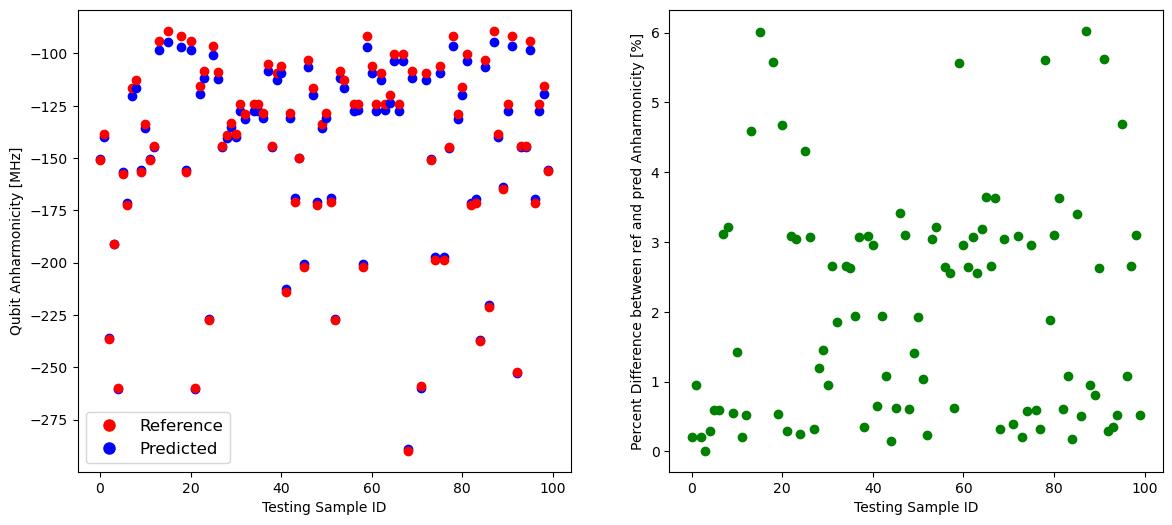

In [7]:
fig,ax = plt.subplots(1,2,figsize = (14,6))
Samples = simulation_results.Sample.to_numpy()

over2 = []
under2 = []
all_diffs_alpha = []

for sample in Samples:
    
    predicted_alpha = eval(simulation_results[simulation_results.Sample == sample].pred_H_params.iloc[0])["anharmonicity_MHz"]
    reference_alpha = eval(simulation_results[simulation_results.Sample == sample].ref_H_params.iloc[0])["anharmonicity_MHz"]

    diff_alpha = percentDiff(reference_alpha,predicted_alpha)
    all_diffs_alpha.append(diff_alpha)
    if diff_alpha < 2:
        under2.append([sample,predicted_alpha,diff_alpha])
    else:
        over2.append([sample,predicted_alpha,diff_alpha])
        
    ax[0].scatter([sample],[predicted_alpha],color = 'blue')
    ax[0].scatter([sample],[reference_alpha],color = 'red')
    
    ax[0].set_xlabel("Testing Sample ID")
    ax[0].set_ylabel("Qubit Anharmonicity [MHz]")

    ax[1].scatter([sample],[diff_alpha],color = 'green')

    ax[1].set_xlabel("Testing Sample ID")
    ax[1].set_ylabel("Percent Difference between ref and pred Anharmonicity [%]")


legend_elements = [
    Line2D([0], [0], marker='o', color='red',
           linestyle='None', markersize=8, label='Reference'),
    Line2D([0], [0], marker='o', color='blue',
           linestyle='None', markersize=8, label='Predicted'),
]

ax[0].legend(handles=legend_elements,fontsize = 12)

## "Olivia-Style" percent difference histograms

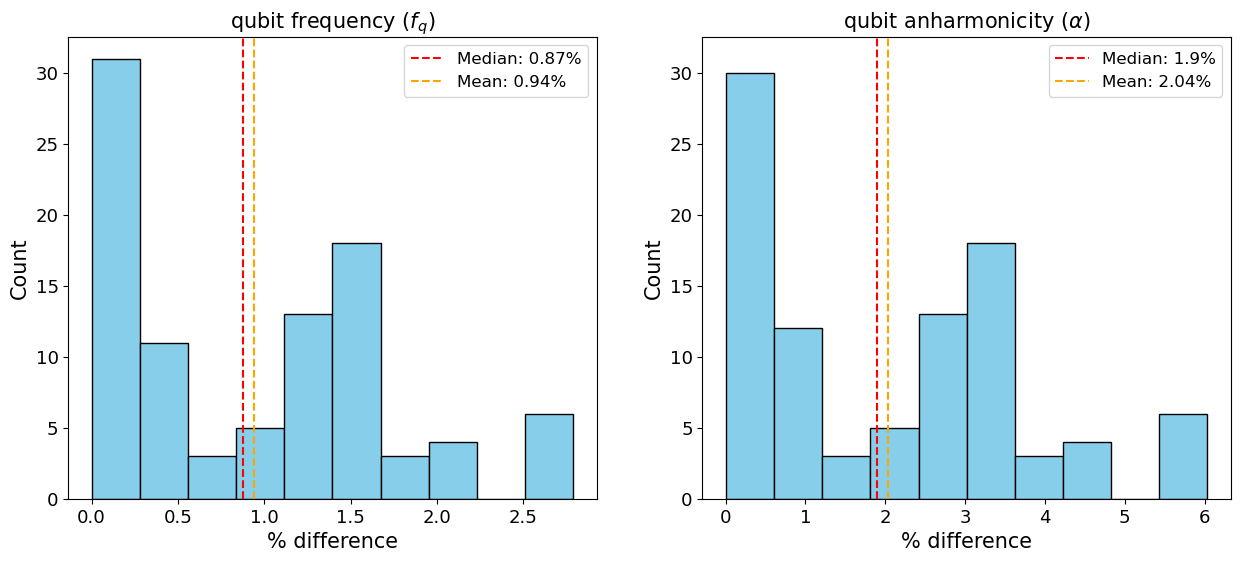

In [8]:
fig,ax = plt.subplots(1,2,figsize = (15,6))
#bins = np.linspace(min(all_diffs_alpha),max(all_diffs_alpha),10)
ax[0].hist(all_diffs_f,ec="black",color = "skyblue")
ax[1].hist(all_diffs_alpha,ec="black",color = "skyblue")

mean_f = np.mean(all_diffs_f)
median_f = np.median(all_diffs_f)
mean_alpha = np.mean(all_diffs_alpha)
median_alpha = np.median(all_diffs_alpha)

ylims = ax[0].get_ylim()
ax[0].set_ylim(ylims[0],ylims[1])
ax[1].set_ylim(ylims[0],ylims[1])

ax[0].vlines(median_f,ylims[0],ylims[1],color = "red",linestyle = "dashed",label = "Median: {}%".format(np.round(median_f,2)))
ax[0].vlines(mean_f,ylims[0],ylims[1],color = "orange",linestyle = "dashed",label = "Mean: {}%".format(np.round(mean_f,2)))
ax[1].vlines(median_alpha,ylims[0],ylims[1],color = "red",linestyle = "dashed",label = "Median: {}%".format(np.round(median_alpha,2)))
ax[1].vlines(mean_alpha,ylims[0],ylims[1],color = "orange",linestyle = "dashed",label = "Mean: {}%".format(np.round(mean_alpha,2)))

ax[0].legend(fontsize = 12)
ax[1].legend(fontsize = 12)

ax[0].set_title(r"qubit frequency ($f_q$)",fontsize = 15)
ax[1].set_title(r"qubit anharmonicity ($\alpha$)",fontsize = 15)
ax[0].set_ylabel("Count",fontsize = 15)
ax[1].set_ylabel("Count",fontsize = 15)
ax[0].set_xlabel("% difference",fontsize = 15)
ax[1].set_xlabel("% difference",fontsize = 15)

ax[0].tick_params("x",labelsize = 13)
ax[0].tick_params("y",labelsize = 13)
ax[1].tick_params("y",labelsize = 13)
ax[1].tick_params("x",labelsize = 13)

plt.savefig("inverse+surrogate_ansys_validation.pdf",bbox_inches='tight')

In [27]:
this_dict = {"frequency":all_diffs_f,"anharmonicity":all_diffs_alpha}
pd.DataFrame(this_dict).to_csv("inverse+surrogate_percentErrors.csv",index=False)